# Evaluation Metric Statistics and Shapley Value Statistics
Please find the original generated event logs for the purpose of SHAining into Process Discovery as a [Zenodo Artifact](https://zenodo.org/records/15047390). This notebook presents  all metric evaluation results (fitness, precision, fitness, cfc, size and execution time) for analyzed algorithms (inductive, ilp, sm1), as well as all their Shapley Values per feature value combination. 

## Evaluation Metric Statistics
show that our comprehensive investigation with generated event logs, covers a wide spectrum for most evaluation metrics, demonstrating the significance of our analysis.

In [1]:
from gedi.plotter import FeaturesPlotter
import pandas as pd
import numpy as np

SUCCESS: Saved , plot_type='boxplot' plot in ../output/plots/boxplots_8fts_3miners_ind_ilp_sm1_benchmark_4fts_50314gEL_of23068.jpg
SUCCESS: Saved , plot_type='boxplot' plot in ../output/plots/boxplots_8fts_3miners_ind_ilp_sm1_benchmark_4fts_50314gEL_of34612.jpg
SUCCESS: Saved , plot_type='boxplot' plot in ../output/plots/boxplots_8fts_3miners_ind_ilp_sm1_benchmark_4fts_50314gEL_of30197.jpg


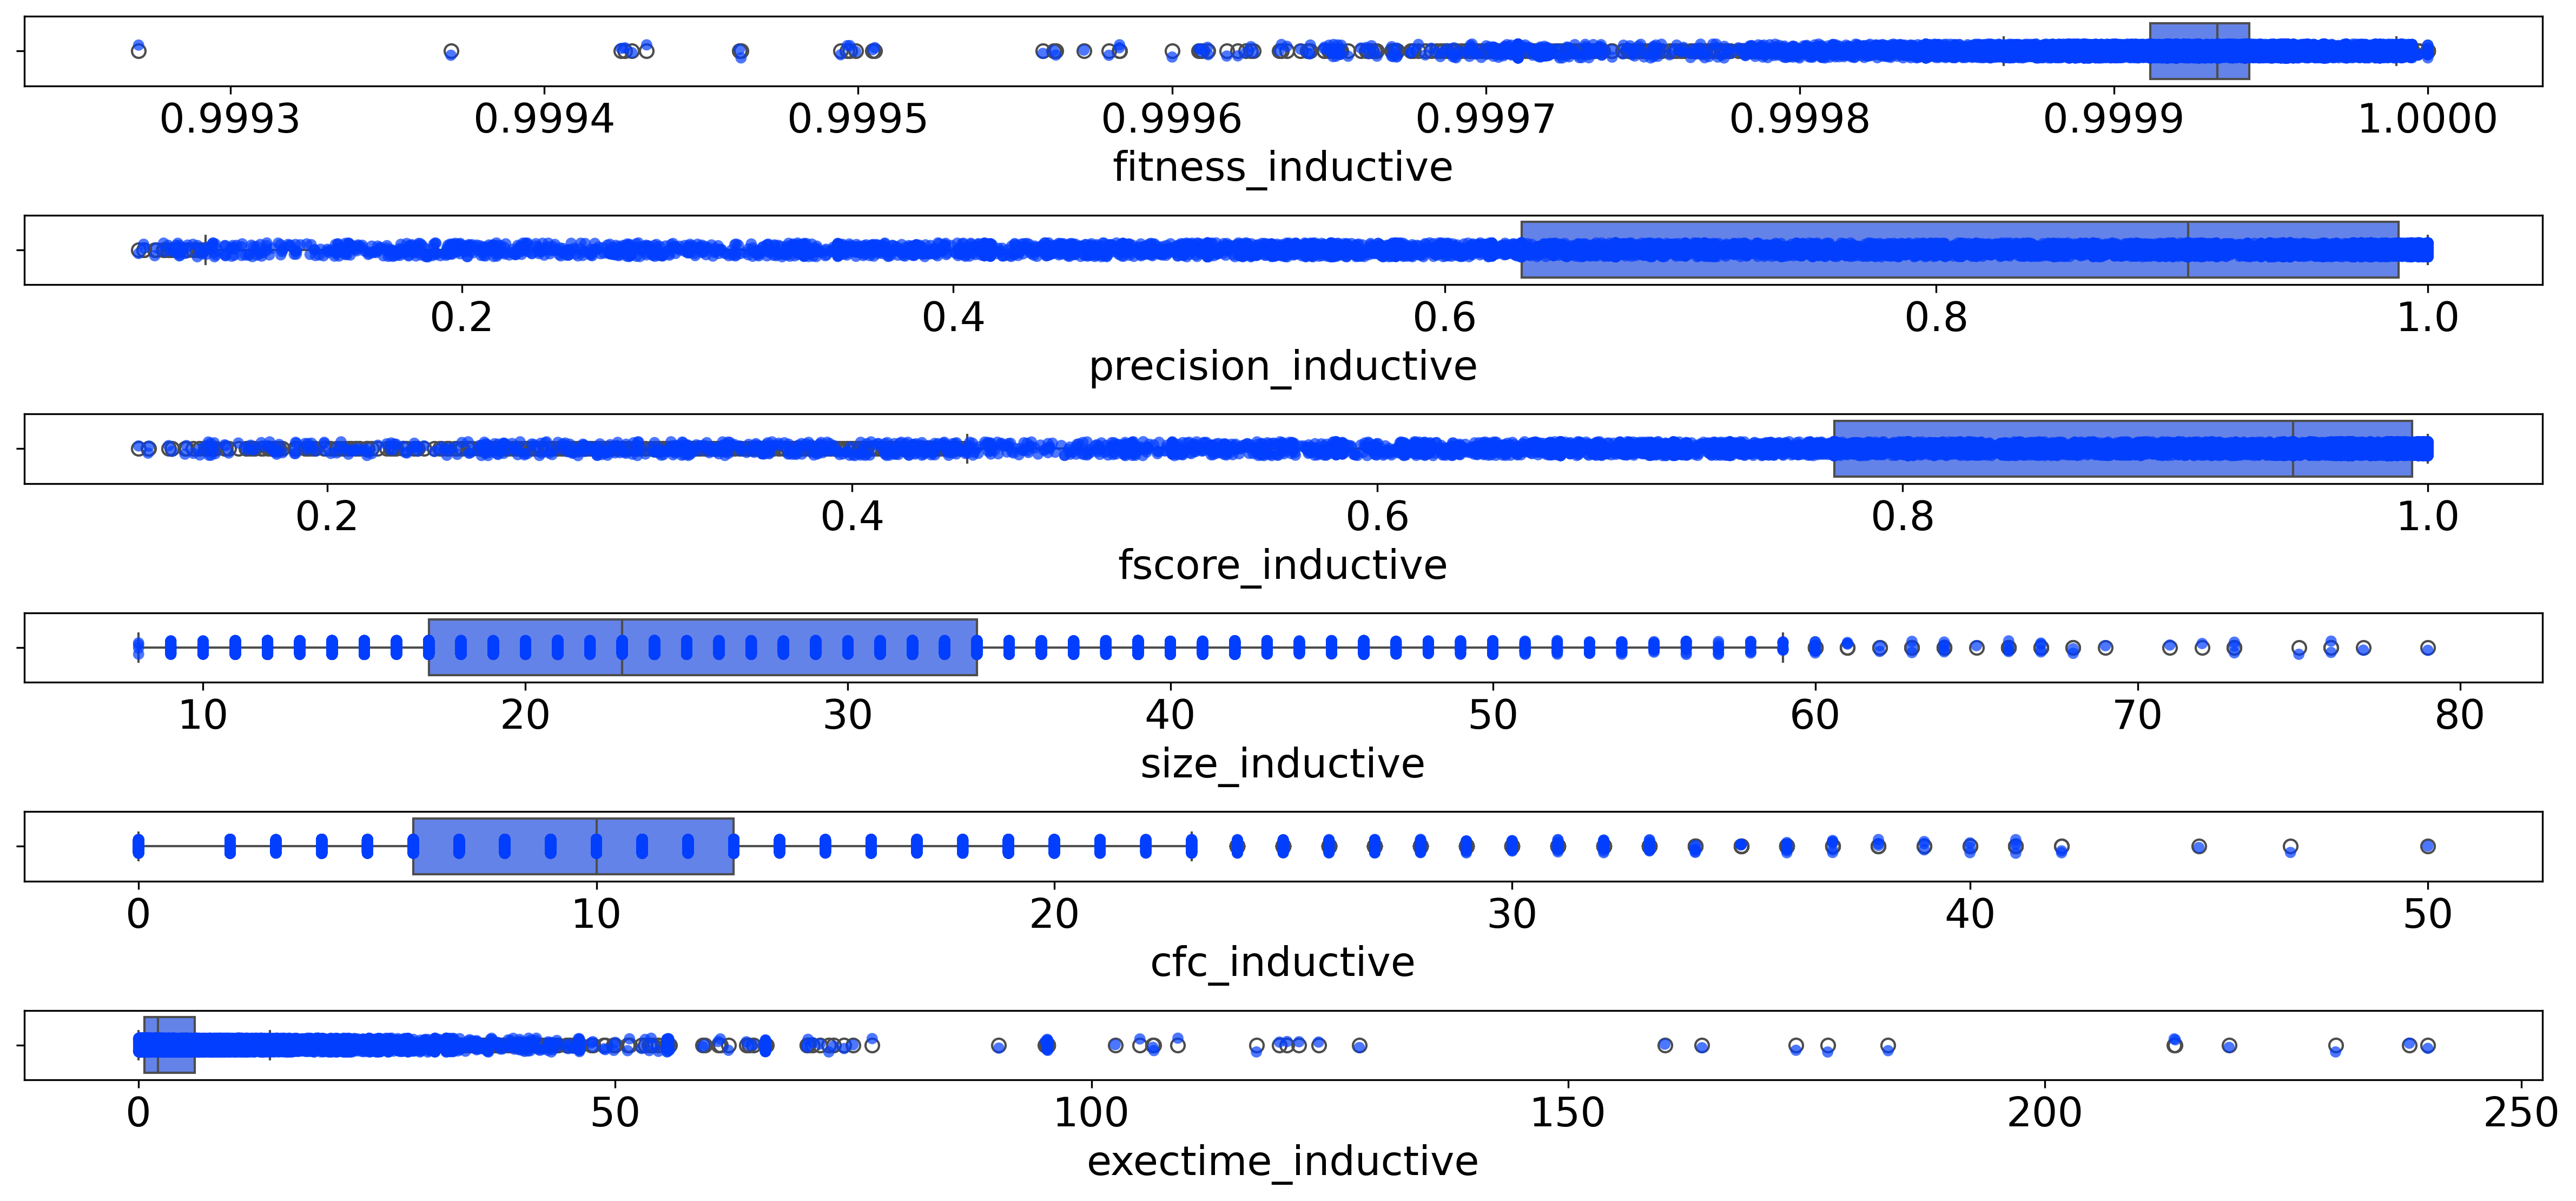

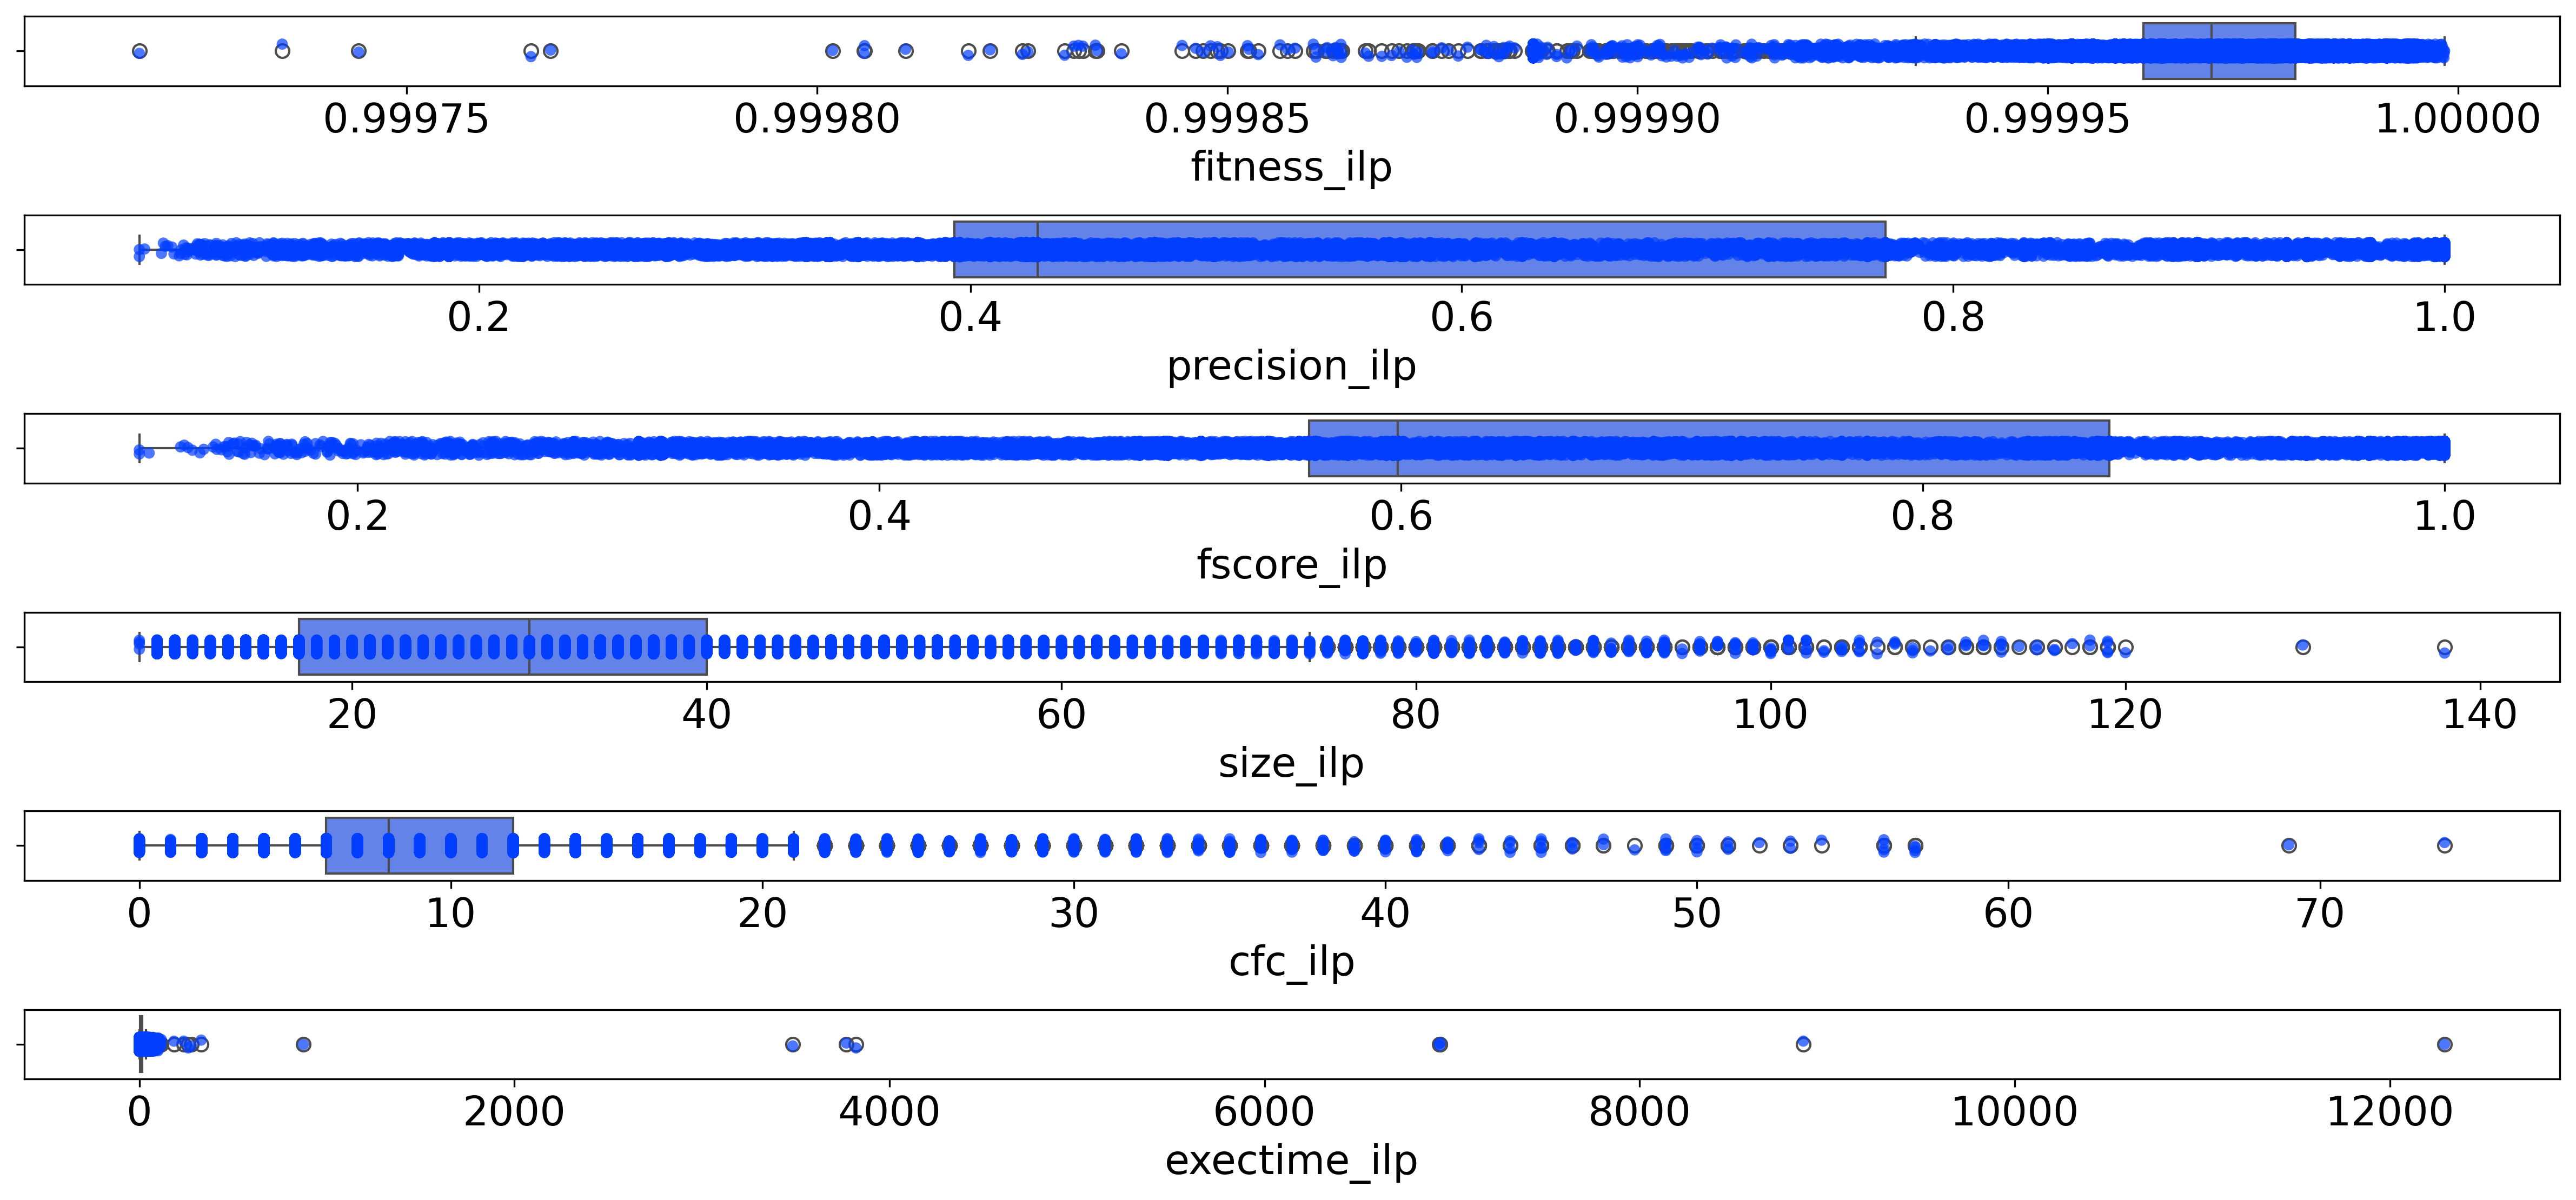

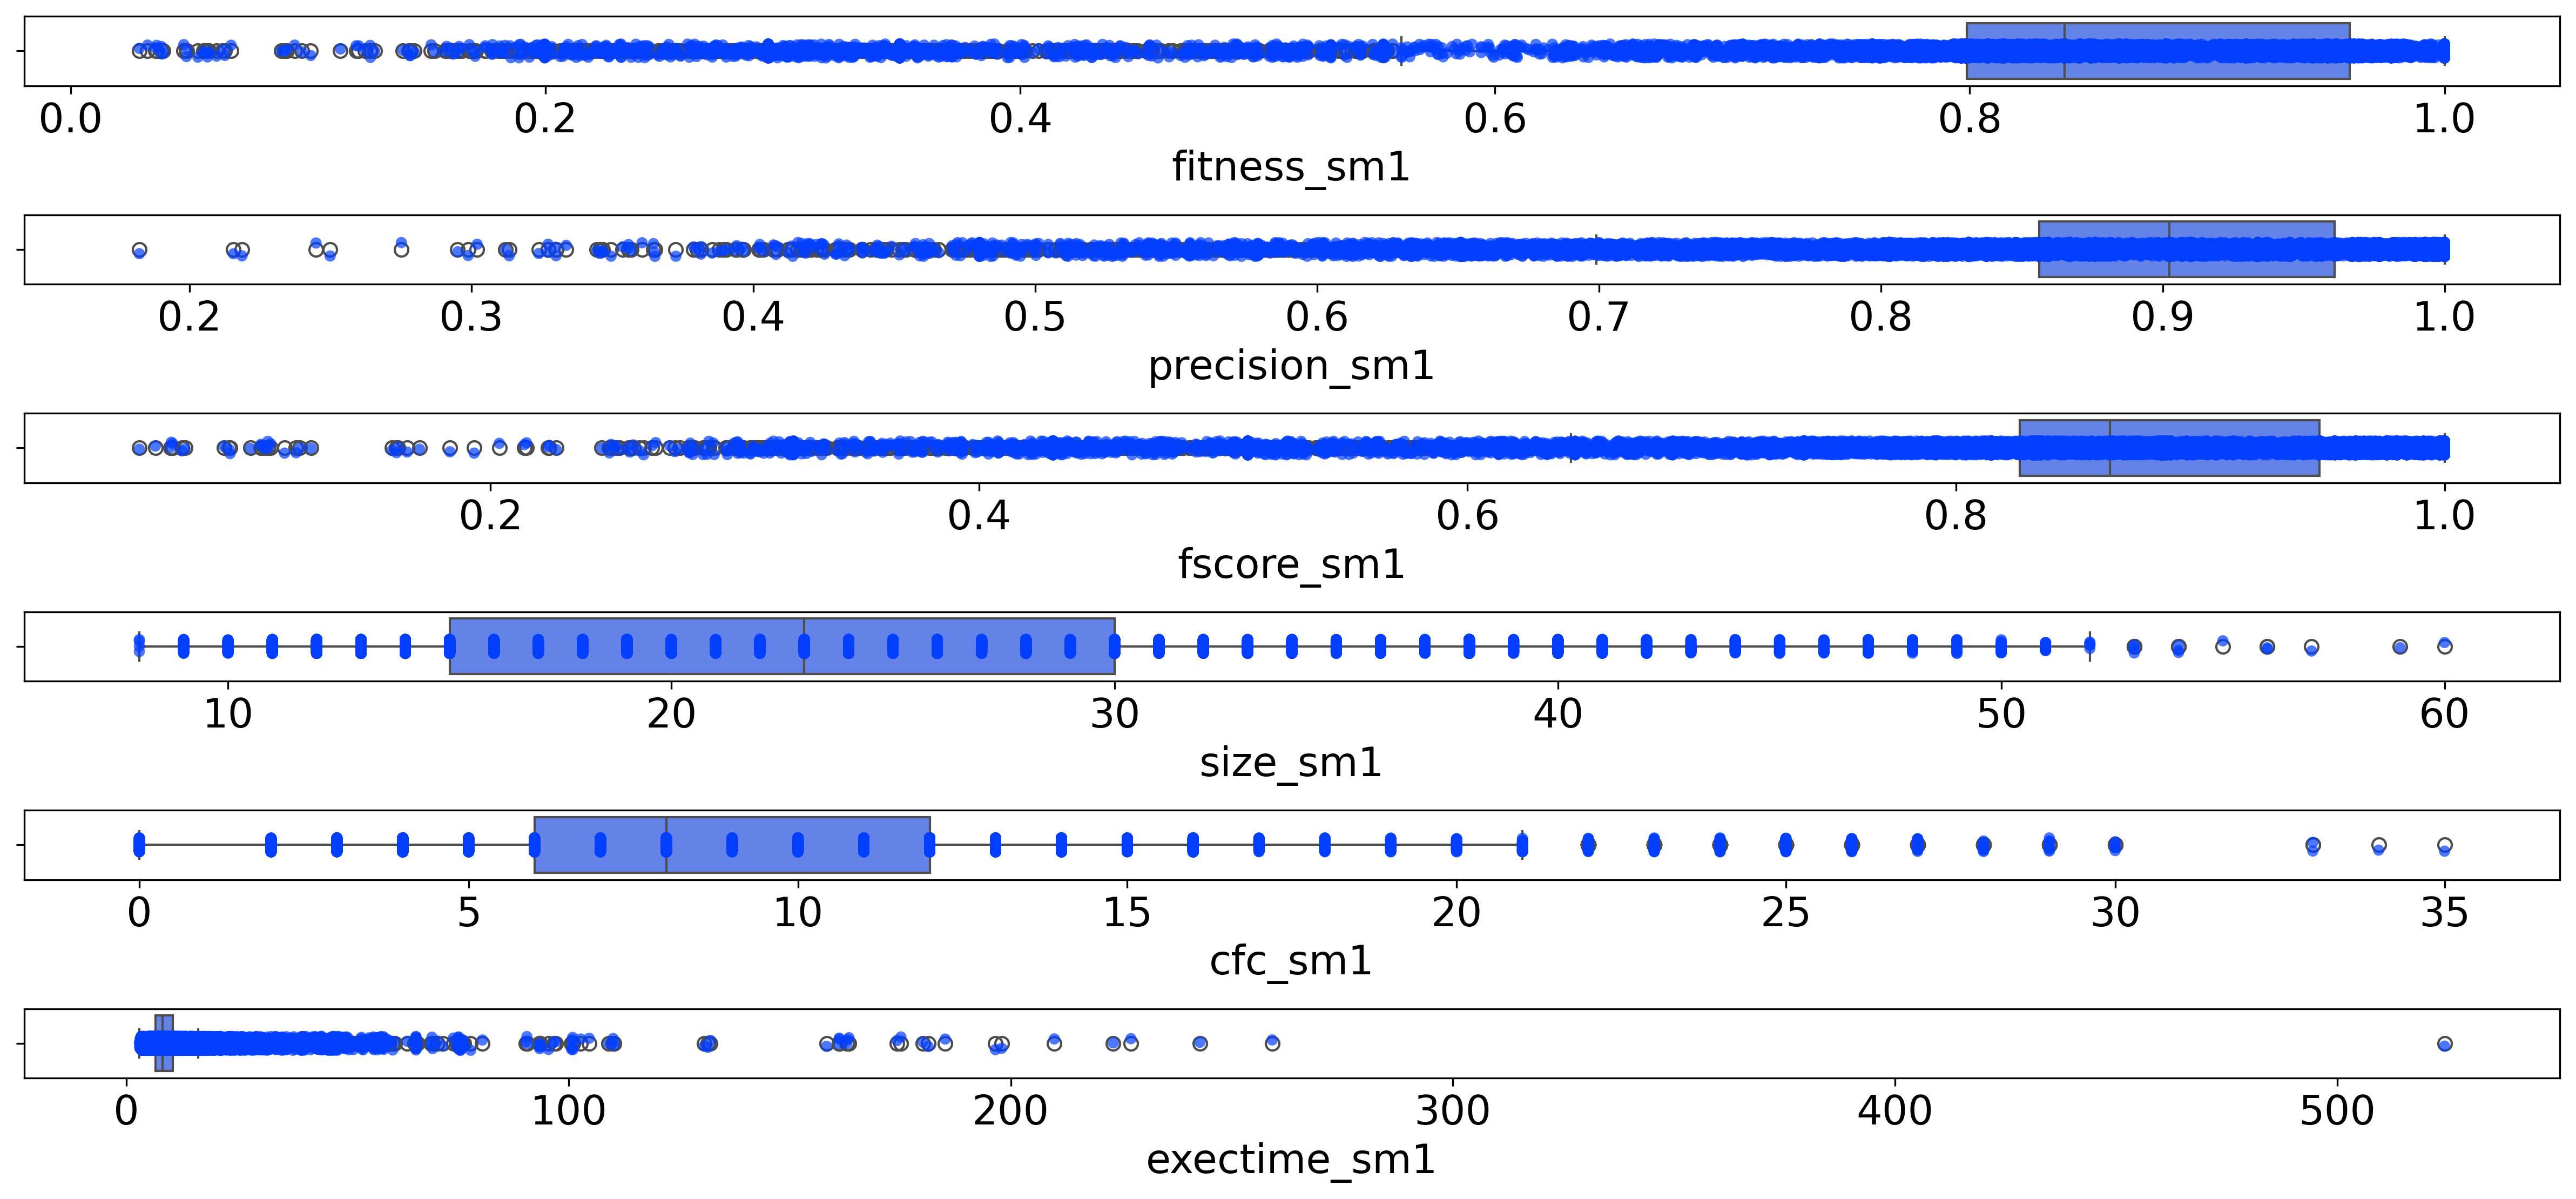

In [2]:
model_params = {"output_path":"../output/plots", "input_path":"../data/icpm_25/8fts_3miners_ind_ilp_sm1_benchmark.csv",
                "real_eventlog_path": "../../gedi/data/BaselineED_bench.csv",
                "plot_type":"boxplot", "font_size":18, "boxplot_widt":8}
generated =pd.read_csv("../data/icpm_25/8fts_3miners_ind_ilp_sm1_benchmark.csv")
generated['fitness_sm1'].replace(-1, np.nan, inplace=True)

miners = ['inductive', 'ilp', 'sm1']
for miner in miners:
    metrics = ['fitness', 'precision', 'fscore', 'size', 'cfc', 'exectime']
    metrics = [(x+'_'+miner) for x in metrics]
    generated_heu = generated[metrics]
    FeaturesPlotter( generated_heu, model_params)

## Shapley Value Statistics
show the feature importance. Aggregations per metric and per miner in this case show that our feature impact variate within metric and miner, covering a broad spectrum of the obtained evaluation measurements.

In [3]:
model_params = {"output_path":"../output/plots", "input_path":"../data/icpm_25/8fts_3miners_ind_ilp_sm1_shapley.csv",
                "real_eventlog_path": "../../gedi/data/BaselineED_bench.csv",
                "plot_type":"boxplot", "font_size":18, "boxplot_widt":8}
shapley =pd.read_csv("../data/icpm_25/8fts_3miners_ind_ilp_sm1_shapley.csv")
#generated['fitness_sm1'].replace(-1, np.nan, inplace=True)
shapley = shapley[~shapley['metric'].isin(['benchtime', 'pnsize'])]
shapley.shape
shapley.head()

,algorithm,metric,feature_name,feature_value,shapley_value
4671,inductive,cfc,aq1,6413,11.833333
4672,inductive,cfc,svo,758,-5.166667
4673,inductive,cfc,tlv,2776,4.333333
4674,inductive,cfc,aq1,6413,9.833333
4675,inductive,cfc,svo,758,-4.166667


In [4]:
df = pd.DataFrame(shapley)

df['group_id'] = df.groupby(['algorithm', 'metric']).cumcount() // 3

# Build full metric_algorithm name
df['metric_alg'] = df['metric'] + '_' + df['algorithm']

# Pivot: rows = (group, feature), columns = metric_alg, values = shapley
reshaped = df.pivot_table(
    index=['group_id', 'feature_name', 'feature_value'],
    columns='metric_alg',
    values='shapley_value',
    aggfunc='first'  # use 'first' to avoid errors on duplicates
).reset_index()

# Optional: flatten column index
reshaped.columns.name = None  # remove pivot table column name

SUCCESS: Saved , plot_type='boxplot' plot in ../output/plots/boxplots_8fts_3miners_ind_ilp_sm1_shapley_4fts_4671gEL_of4671.jpg
SUCCESS: Saved , plot_type='boxplot' plot in ../output/plots/boxplots_8fts_3miners_ind_ilp_sm1_shapley_4fts_4671gEL_of4671.jpg
SUCCESS: Saved , plot_type='boxplot' plot in ../output/plots/boxplots_8fts_3miners_ind_ilp_sm1_shapley_4fts_4671gEL_of4671.jpg


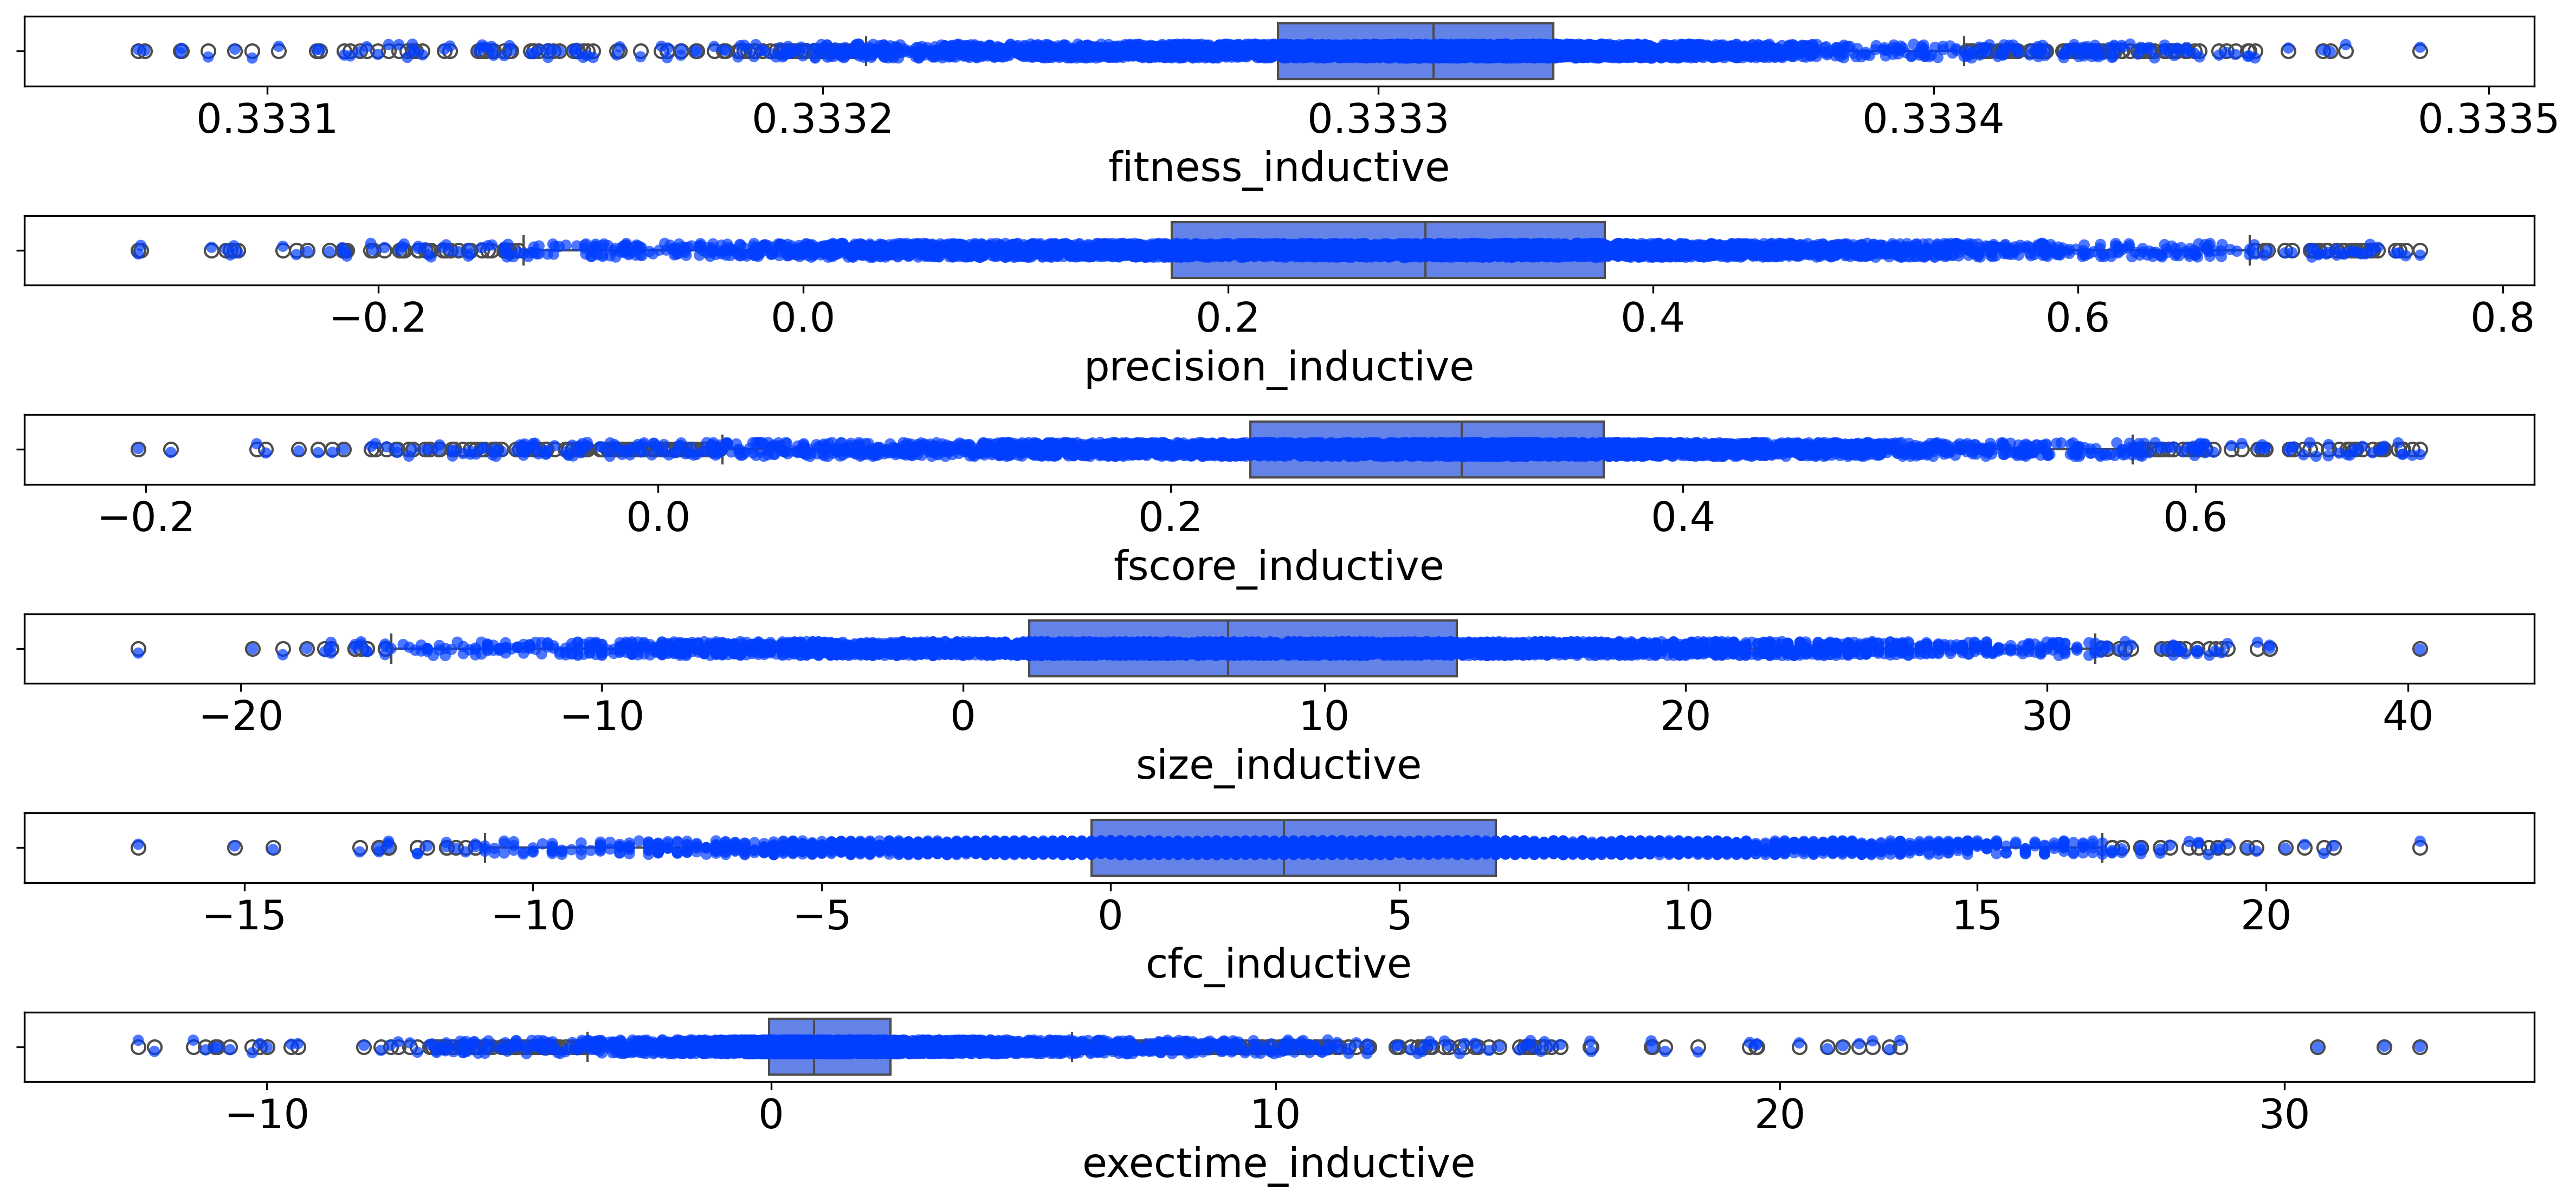

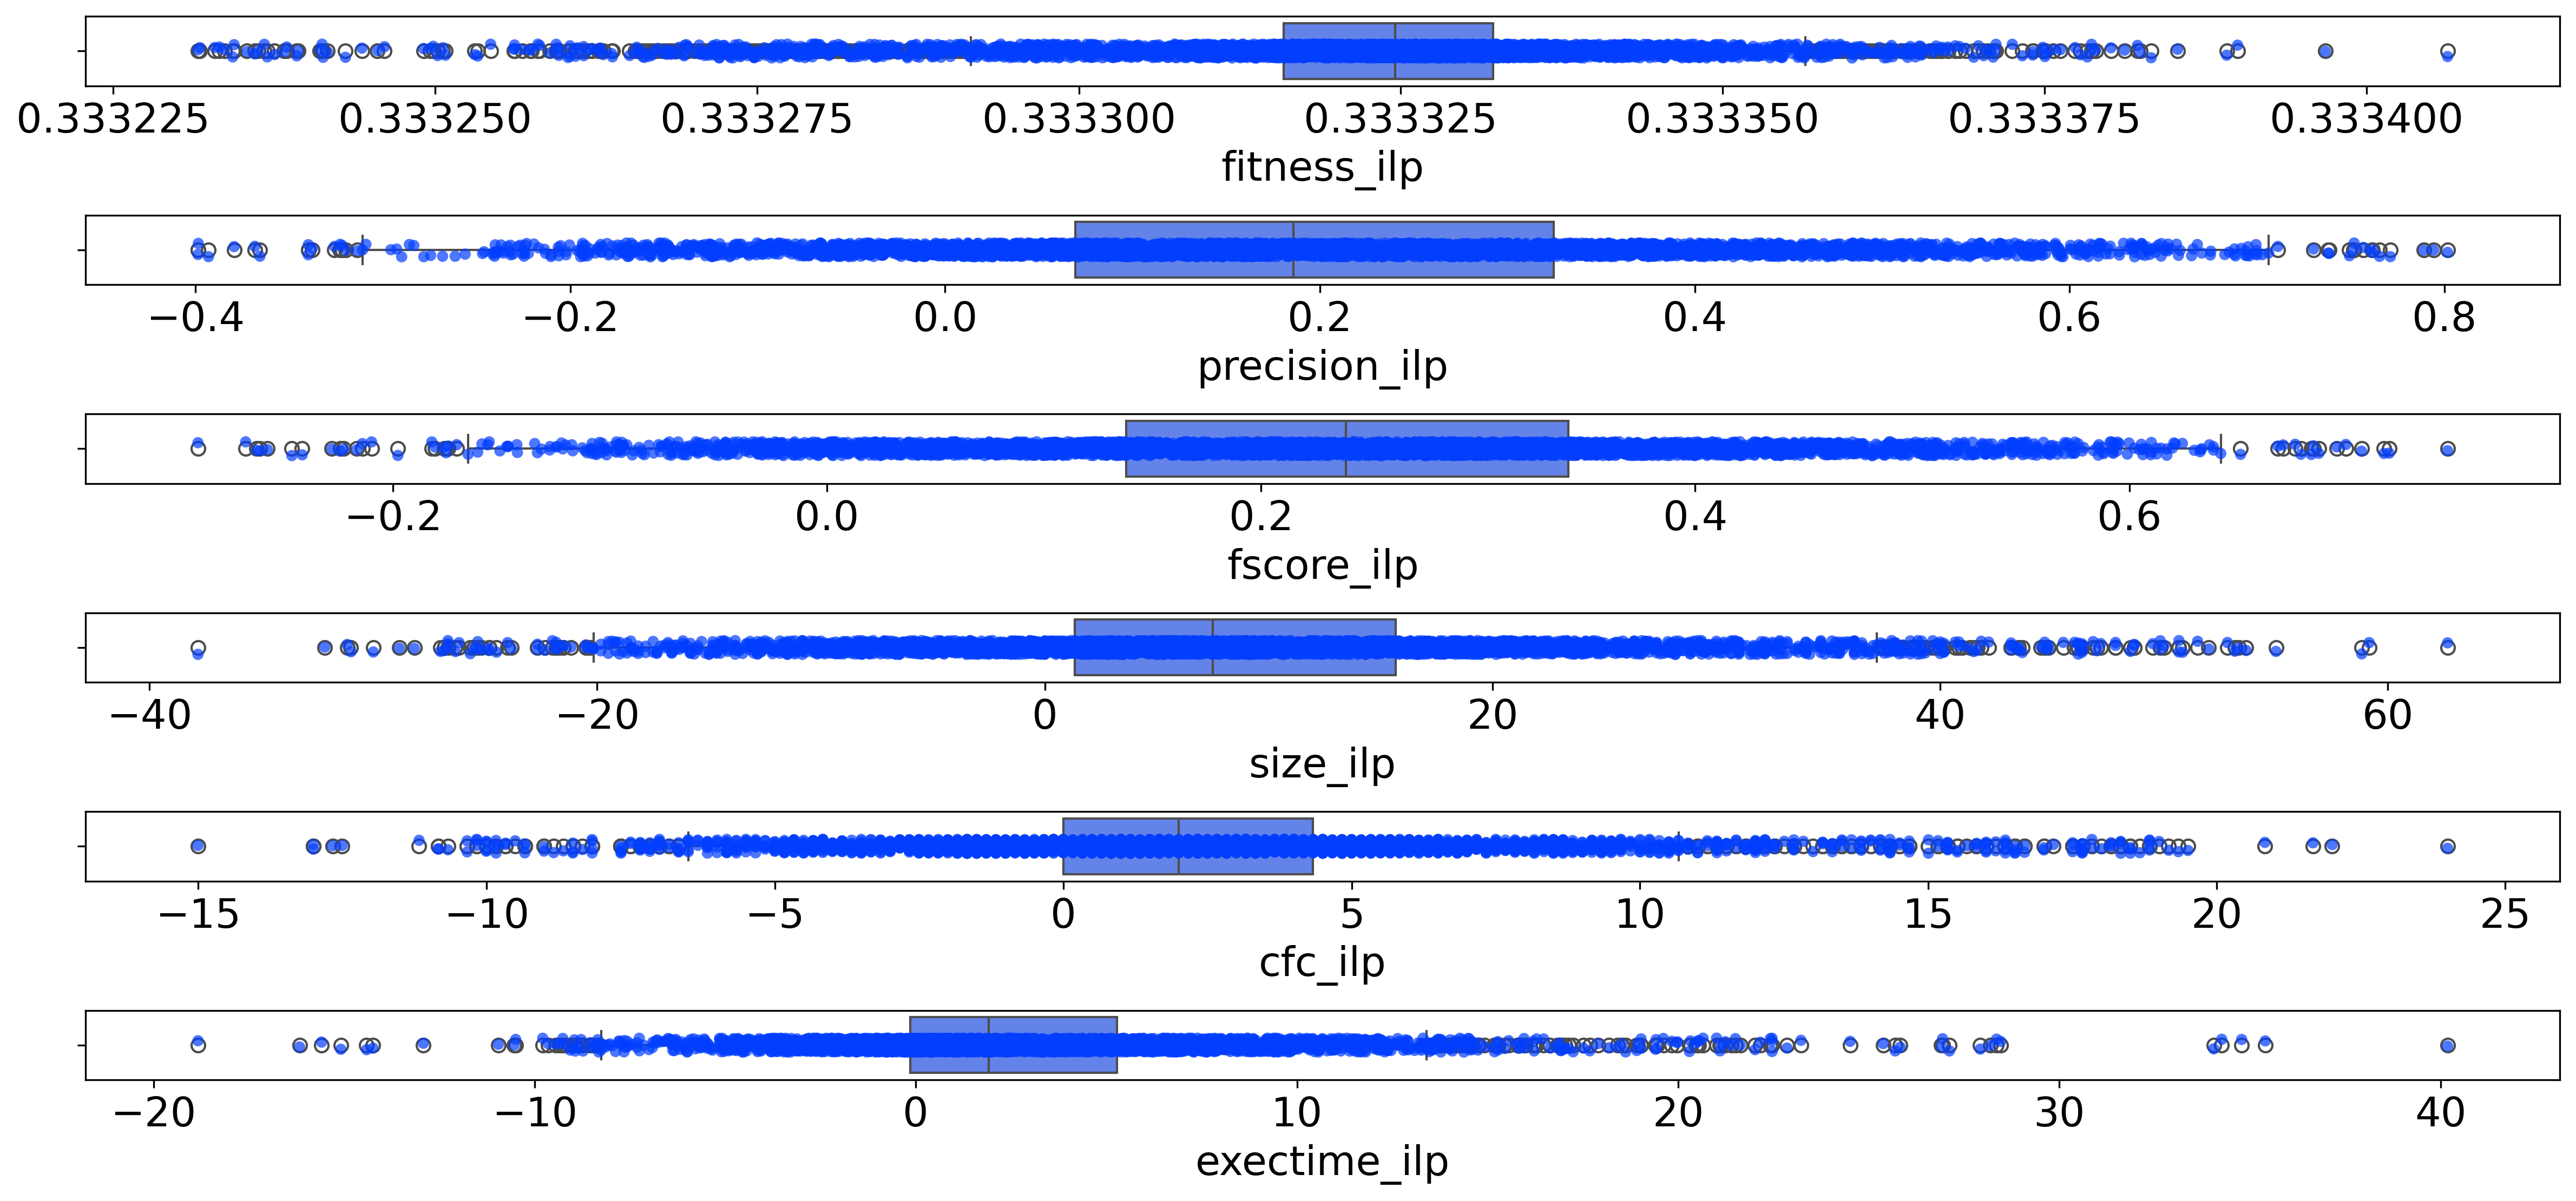

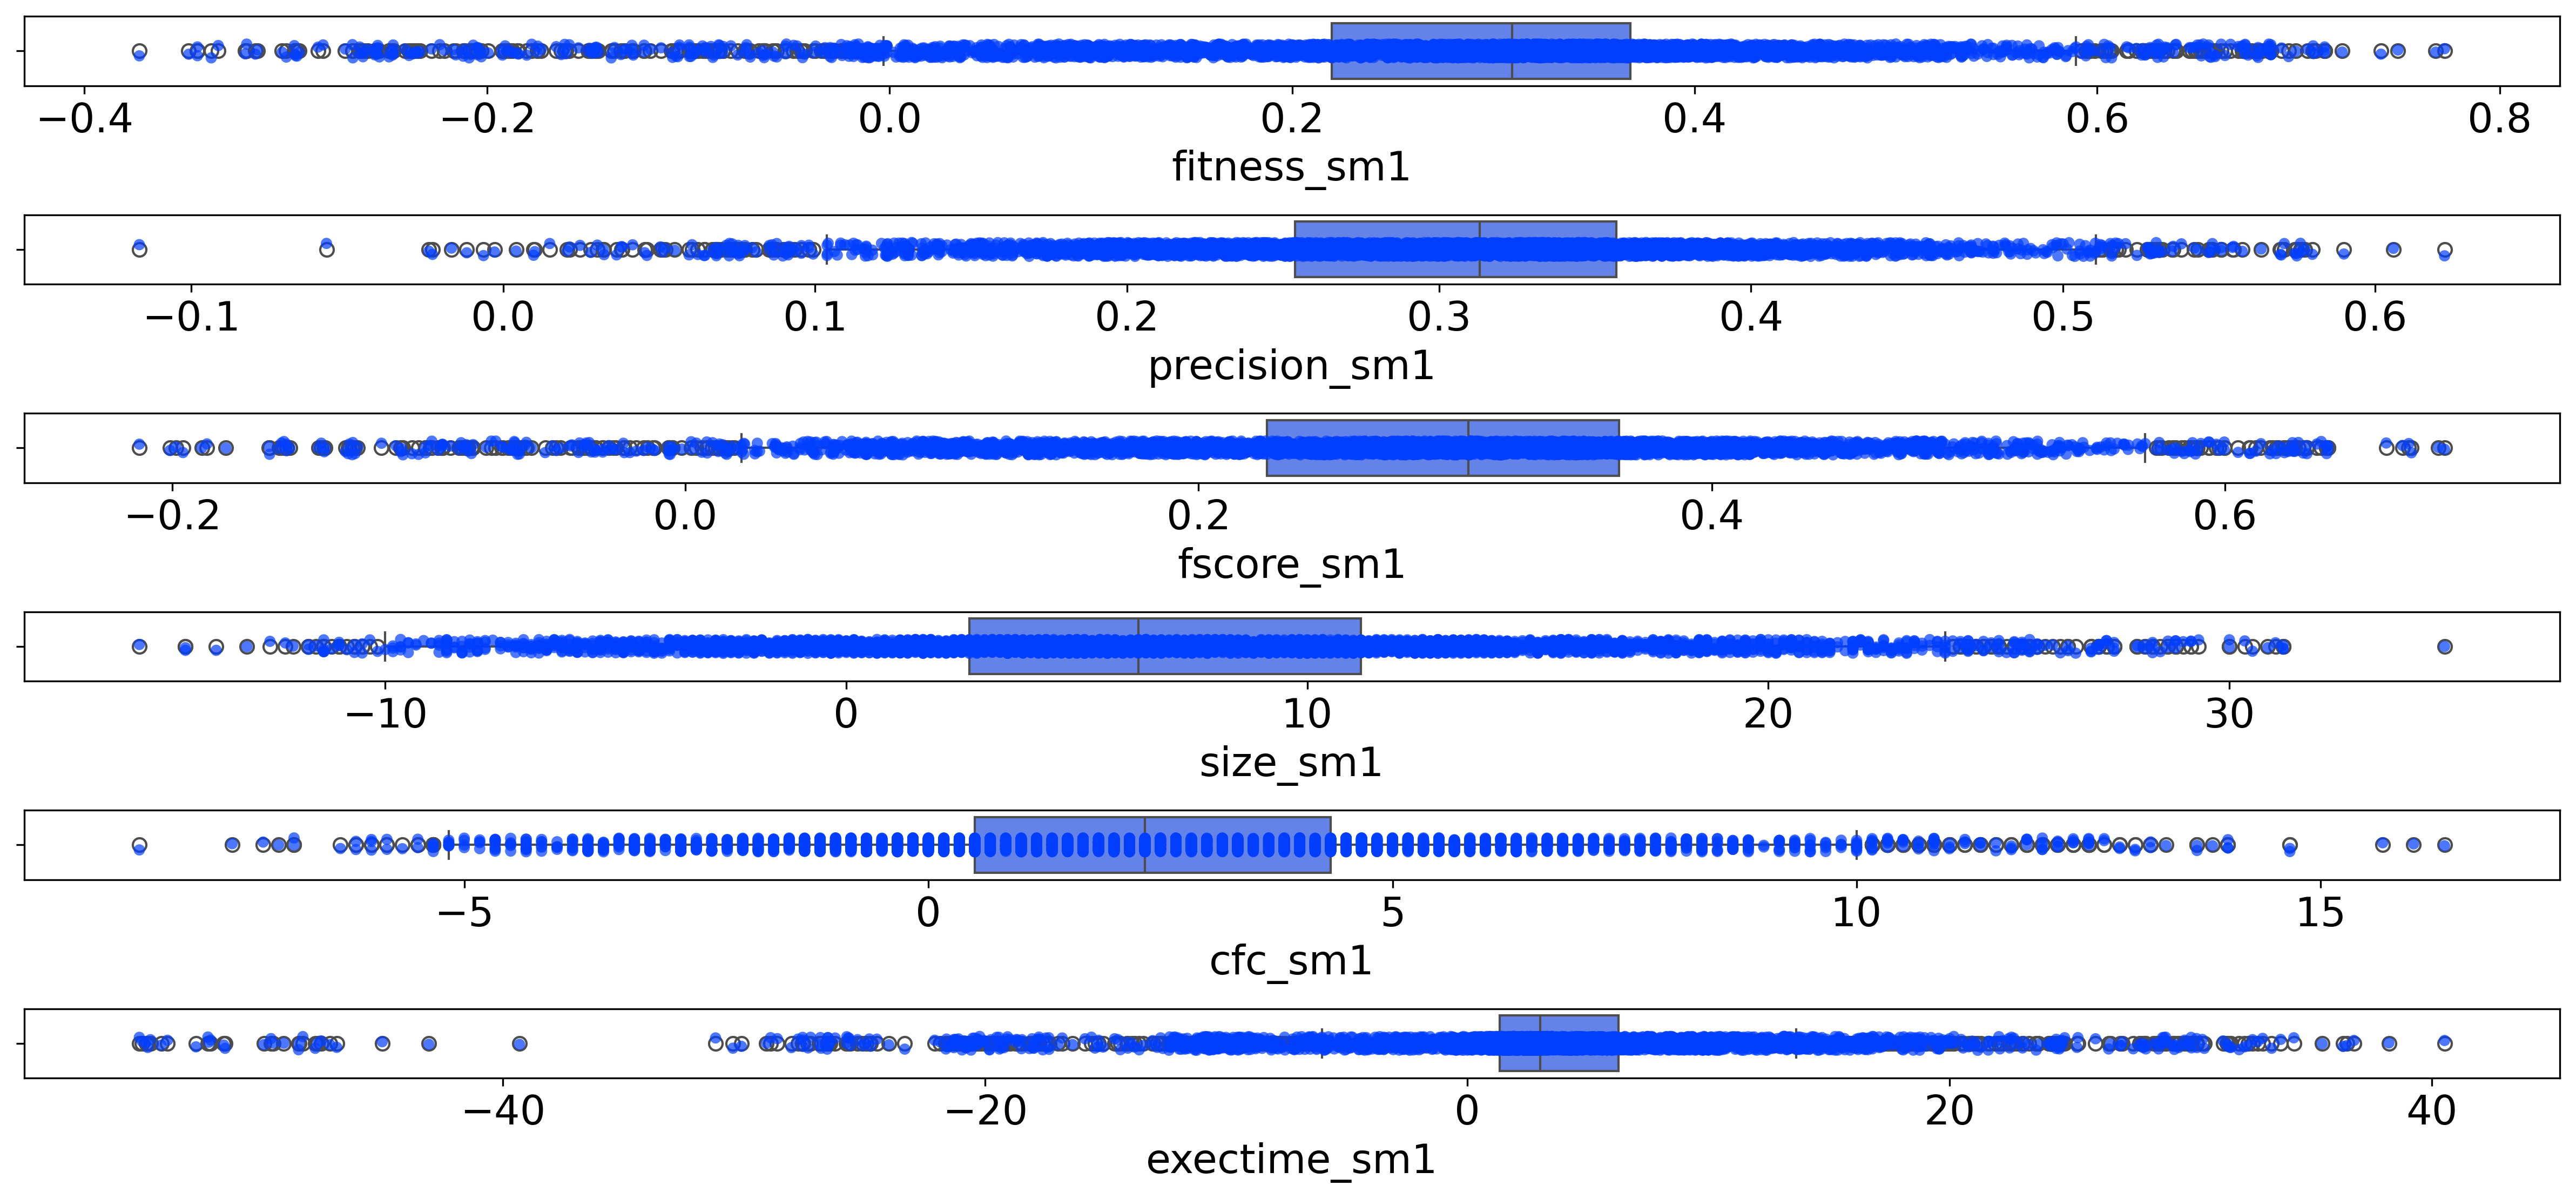

In [5]:
miners = ['inductive', 'ilp', 'sm1']
for miner in miners:
    metrics = ['fitness', 'precision', 'fscore', 'size', 'cfc', 'exectime']
    metrics = [(x+'_'+miner) for x in metrics]
    generated_heu = reshaped[metrics]
    FeaturesPlotter( generated_heu, model_params)